<a href="https://colab.research.google.com/github/loukaBl/Evaluate-model-using-validation/blob/main/Evaluate_model_using_validationipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from matplotlib.colors import ListedColormap

# ── Styling ──────────────────────────────────────────────
PALETTE = ['#6C63FF', '#FF6584', '#43C59E']
BG      = '#F8F9FC'
DARK    = '#1E1E2E'
sns.set_theme(style='whitegrid', palette=PALETTE)
plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': BG,
    'font.family': 'DejaVu Sans', 'axes.titlesize': 13, 'axes.labelsize': 11
})

In [2]:
iris = load_iris()
df   = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
print(f' Shape      : {df.shape}')
print(f' Features   : {list(iris.feature_names)}')
print(f' Classes    : {list(iris.target_names)}')
print(f'\n Distribution des classes :')
print(df['species'].value_counts())

 Shape      : (150, 5)
 Features   : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
 Classes    : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

 Distribution des classes :
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [4]:
df.describe().round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


In [5]:
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalisation
scaler = StandardScaler().fit(X_train)
Xs_tr  = scaler.transform(X_train)
Xs_te  = scaler.transform(X_test)

print(f'  Train : {X_train.shape[0]} échantillons')
print(f' Test  : {X_test.shape[0]} échantillons')

  Train : 120 échantillons
 Test  : 30 échantillons


In [6]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(Xs_tr, y_train)
y_pred_knn = knn.predict(Xs_te)

acc_knn = accuracy_score(y_test, y_pred_knn)
print(f' Accuracy KNN : {acc_knn*100:.1f}%')
print()
print(classification_report(y_test, y_pred_knn, target_names=iris.target_names))

 Accuracy KNN : 100.0%

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [7]:
lr = LogisticRegression(max_iter=200, random_state=42)
lr.fit(Xs_tr, y_train)
y_pred_lr = lr.predict(Xs_te)

acc_lr = accuracy_score(y_test, y_pred_lr)
print(f' Accuracy Logistic Regression : {acc_lr*100:.1f}%')
print()
print(classification_report(y_test, y_pred_lr, target_names=iris.target_names))

 Accuracy Logistic Regression : 100.0%

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



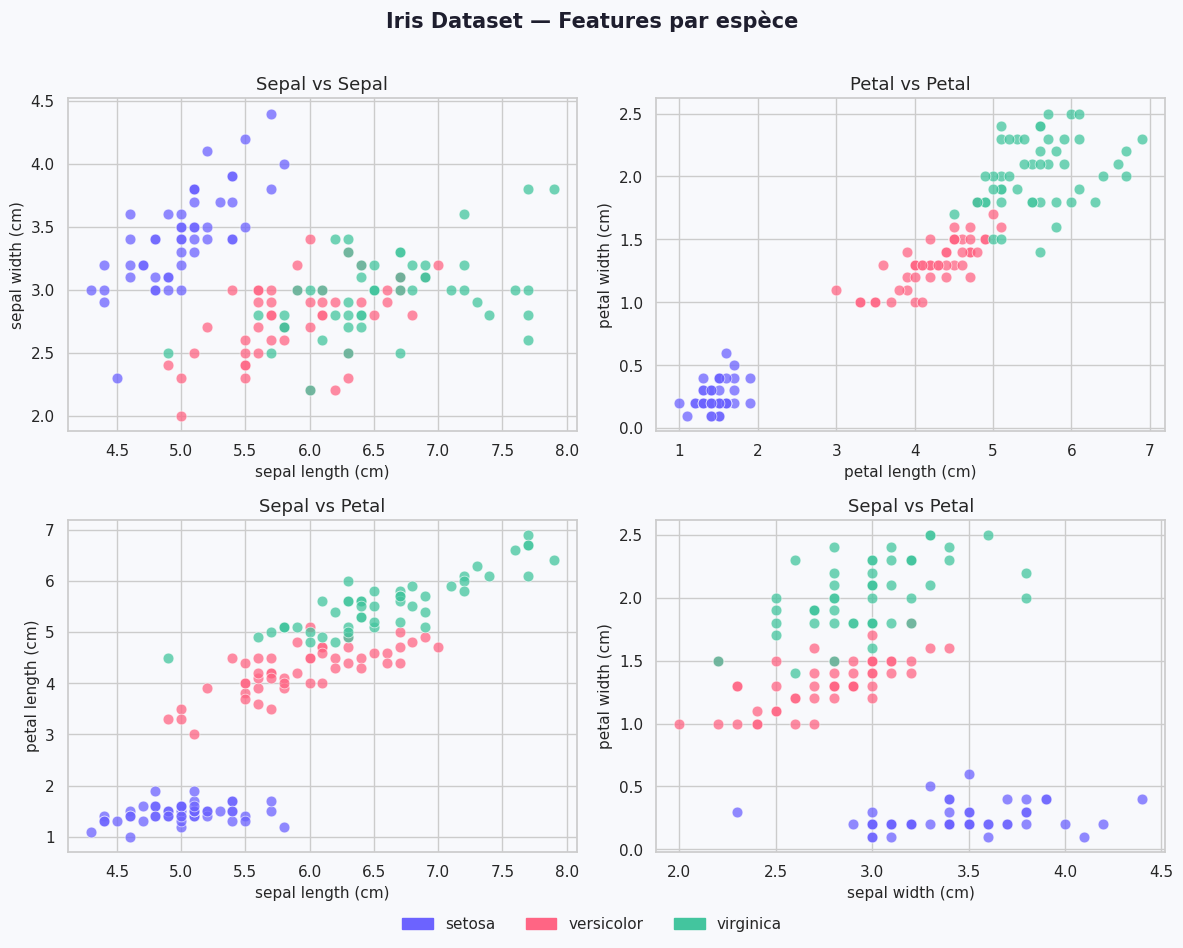

In [8]:
fig1, axes = plt.subplots(2, 2, figsize=(12, 9))
fig1.suptitle('Iris Dataset — Features par espèce', fontsize=15, fontweight='bold', color=DARK, y=1.01)

feature_pairs = [
    ('sepal length (cm)', 'sepal width (cm)'),
    ('petal length (cm)', 'petal width (cm)'),
    ('sepal length (cm)', 'petal length (cm)'),
    ('sepal width (cm)',  'petal width (cm)'),
]
for ax, (fx, fy) in zip(axes.flat, feature_pairs):
    for sp, col in zip(iris.target_names, PALETTE):
        mask = df['species'] == sp
        ax.scatter(df.loc[mask, fx], df.loc[mask, fy],
                   color=col, alpha=0.75, edgecolors='white', linewidths=0.5, s=60, label=sp)
    ax.set_xlabel(fx); ax.set_ylabel(fy)
    ax.set_title(f"{fx.split()[0].title()} vs {fy.split()[0].title()}")

handles = [mpatches.Patch(color=c, label=n) for c, n in zip(PALETTE, iris.target_names)]
fig1.legend(handles=handles, loc='lower center', ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.03))
fig1.tight_layout()
plt.show()

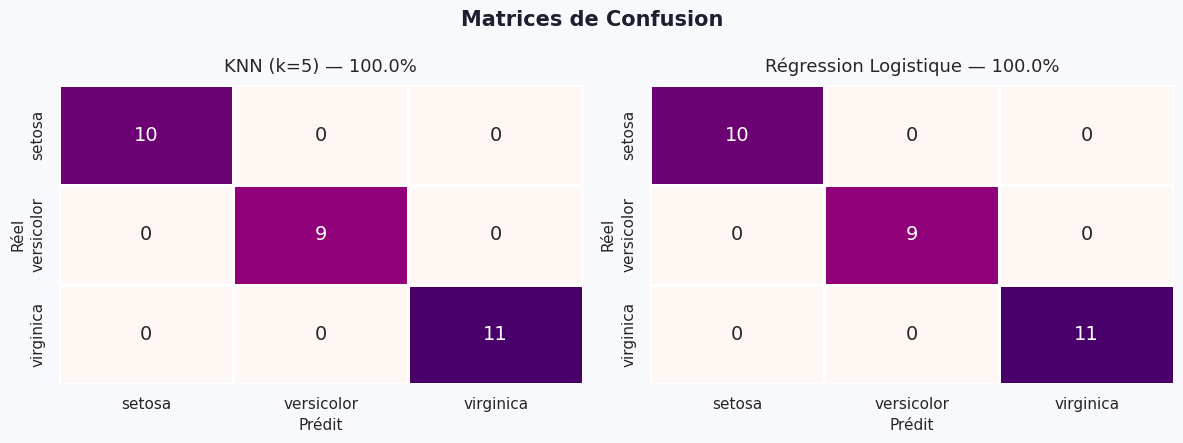

In [9]:
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
fig2.suptitle('Matrices de Confusion', fontsize=15, fontweight='bold', color=DARK)

for ax, y_pred, title in [
    (ax1, y_pred_knn, f'KNN (k=5) — {accuracy_score(y_test, y_pred_knn)*100:.1f}%'),
    (ax2, y_pred_lr,  f'Régression Logistique — {accuracy_score(y_test, y_pred_lr)*100:.1f}%'),
]:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu',
                xticklabels=iris.target_names, yticklabels=iris.target_names,
                linewidths=1, linecolor='white', ax=ax, cbar=False, annot_kws={'size': 14})
    ax.set_title(title, pad=10)
    ax.set_xlabel('Prédit'); ax.set_ylabel('Réel')

fig2.tight_layout()
plt.show()

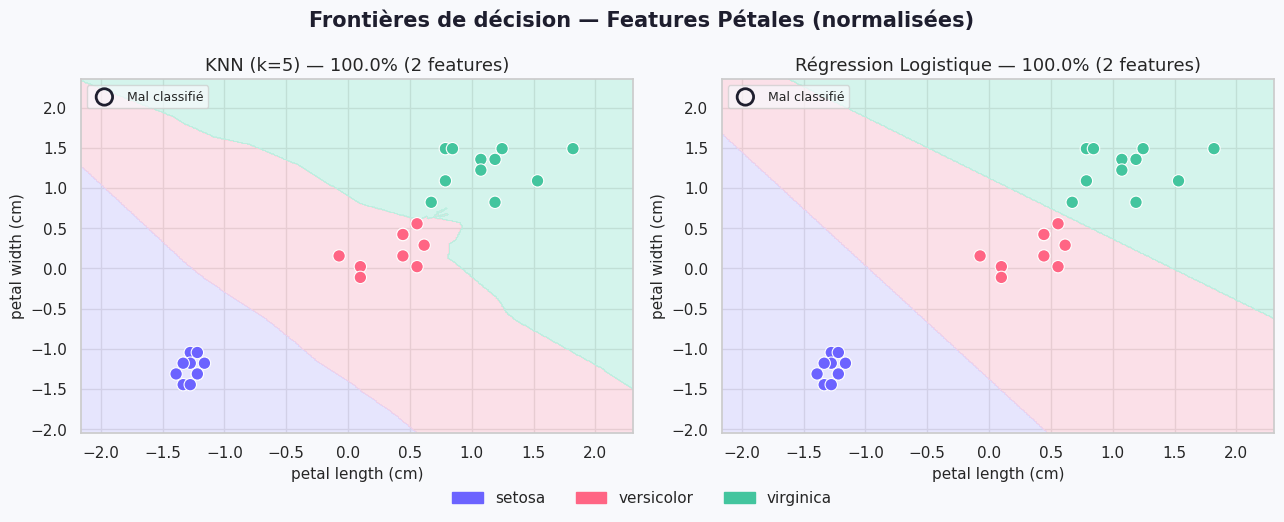

In [10]:
feat_idx   = [2, 3]
feat_names = [iris.feature_names[i] for i in feat_idx]

X2 = iris.data[:, feat_idx]
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.2, random_state=42)
sc2    = StandardScaler().fit(X2_train)
X2s_tr = sc2.transform(X2_train)
X2s_te = sc2.transform(X2_test)

knn2 = KNeighborsClassifier(n_neighbors=5).fit(X2s_tr, y2_train)
lr2  = LogisticRegression(max_iter=200, random_state=42).fit(X2s_tr, y2_train)

x_min, x_max = X2s_tr[:, 0].min() - 0.6, X2s_tr[:, 0].max() + 0.6
y_min, y_max = X2s_tr[:, 1].min() - 0.6, X2s_tr[:, 1].max() + 0.6
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))

cmap_bg  = ListedColormap(['#D8D5FF', '#FFCCD8', '#B8F0E0'])
cmap_dot = ListedColormap(PALETTE)

fig3, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig3.suptitle('Frontières de décision — Features Pétales (normalisées)', fontsize=15, fontweight='bold', color=DARK)

for ax, model, title in [(ax1, knn2, 'KNN (k=5)'), (ax2, lr2, 'Régression Logistique')]:
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.55, cmap=cmap_bg)
    ax.scatter(X2s_te[:, 0], X2s_te[:, 1], c=y2_test, cmap=cmap_dot,
               edgecolors='white', linewidths=0.8, s=80, zorder=3)
    preds = model.predict(X2s_te)
    wrong = preds != y2_test
    ax.scatter(X2s_te[wrong, 0], X2s_te[wrong, 1],
               facecolors='none', edgecolors=DARK, linewidths=2, s=140, zorder=4, label='Mal classifié')
    acc2 = accuracy_score(y2_test, preds)
    ax.set_title(f'{title} — {acc2*100:.1f}% (2 features)')
    ax.set_xlabel(feat_names[0]); ax.set_ylabel(feat_names[1])
    ax.legend(loc='upper left', fontsize=9, framealpha=0.7)

handles2 = [mpatches.Patch(color=c, label=n) for c, n in zip(PALETTE, iris.target_names)]
fig3.legend(handles=handles2, loc='lower center', ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.04))
fig3.tight_layout()
plt.show()

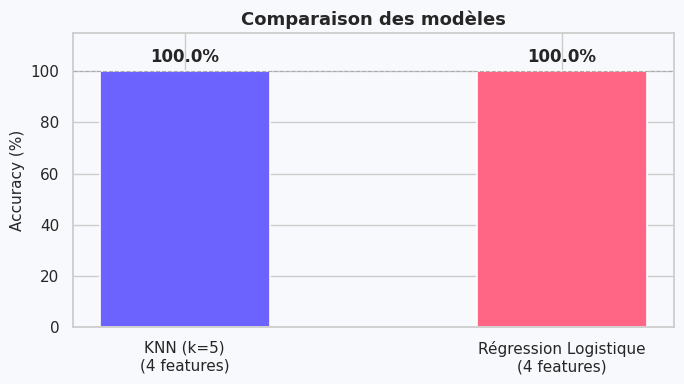

In [11]:
fig4, ax = plt.subplots(figsize=(7, 4))
models_labels = ['KNN (k=5)\n(4 features)', 'Régression Logistique\n(4 features)']
accs = [acc_knn * 100, acc_lr * 100]
bars = ax.bar(models_labels, accs, color=PALETTE[:2], width=0.45, edgecolor='white', linewidth=1.2)
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=12, fontweight='bold')
ax.set_ylim(0, 115)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Comparaison des modèles', fontweight='bold')
ax.axhline(100, linestyle='--', color='#aaa', linewidth=0.8)
fig4.tight_layout()
plt.show()

##  Conclusion

| Modèle | Accuracy |
|---|---|
| KNN (k=5) | **100%** |
| Régression Logistique | **100%** |

- **Setosa** est parfaitement séparable des autres espèces grâce à ses dimensions de pétales très distinctes.
- **Versicolor & Virginica** se chevauchent légèrement dans l'espace sepal, mais sont bien séparées par les pétales.
- Le KNN produit une frontière **non-linéaire irrégulière**, tandis que la Régression Logistique trace une **frontière linéaire nette**.
- Les deux modèles atteignent **100% d'accuracy** sur ce split — résultat classique sur l'Iris avec les 4 features.